### Imports

In [3]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Final comparison table

In [4]:
comparison_results = pd.DataFrame([
    {
        "Model": "Custom CNN",
        "Test Accuracy": 0.9903,
        "Macro Precision": 0.9860,
        "Macro Recall": 0.9869,
        "Macro F1": 0.9864,
        "Weighted F1": 0.9903,
    },
    {
        "Model": "MobileNetV2 Frozen",
        "Test Accuracy": 0.9738,
        "Macro Precision": 0.9419,
        "Macro Recall": 0.9781,
        "Macro F1": 0.9559,
        "Weighted F1": 0.9744,
    },
    {
        "Model": "MobileNetV2 Fine-Tuned",
        "Test Accuracy": 0.9918,
        "Macro Precision": 0.9763,
        "Macro Recall": 0.9871,
        "Macro F1": 0.9814,
        "Weighted F1": 0.9918,
    },
    {
        "Model": "ResNet50 Frozen",
        "Test Accuracy": 0.9880,
        "Macro Precision": 0.9631,
        "Macro Recall": 0.9899,
        "Macro F1": 0.9744,
        "Weighted F1": 0.9883,
    }
])

comparison_results

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Custom CNN,0.9903,0.9860,0.9869,0.9864,0.9903
1,MobileNetV2 Frozen,0.9738,0.9419,0.9781,0.9559,0.9744
2,MobileNetV2 Fine-Tuned,0.9918,0.9763,0.9871,0.9814,0.9918
3,ResNet50 Frozen,0.9880,0.9631,0.9899,0.9744,0.9883


### Convert to percentages for report readability

In [5]:
display_results = comparison_results.copy()

metric_columns = [
    "Test Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted F1",
]

display_results[metric_columns] = (
    display_results[metric_columns] * 100
).round(2)

display_results

,Model,Test Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Custom CNN,99.03,98.60,98.69,98.64,99.03
1,MobileNetV2 Frozen,97.38,94.19,97.81,95.59,97.44
2,MobileNetV2 Fine-Tuned,99.18,97.63,98.71,98.14,99.18
3,ResNet50 Frozen,98.80,96.31,98.99,97.44,98.83


### Visual comparison

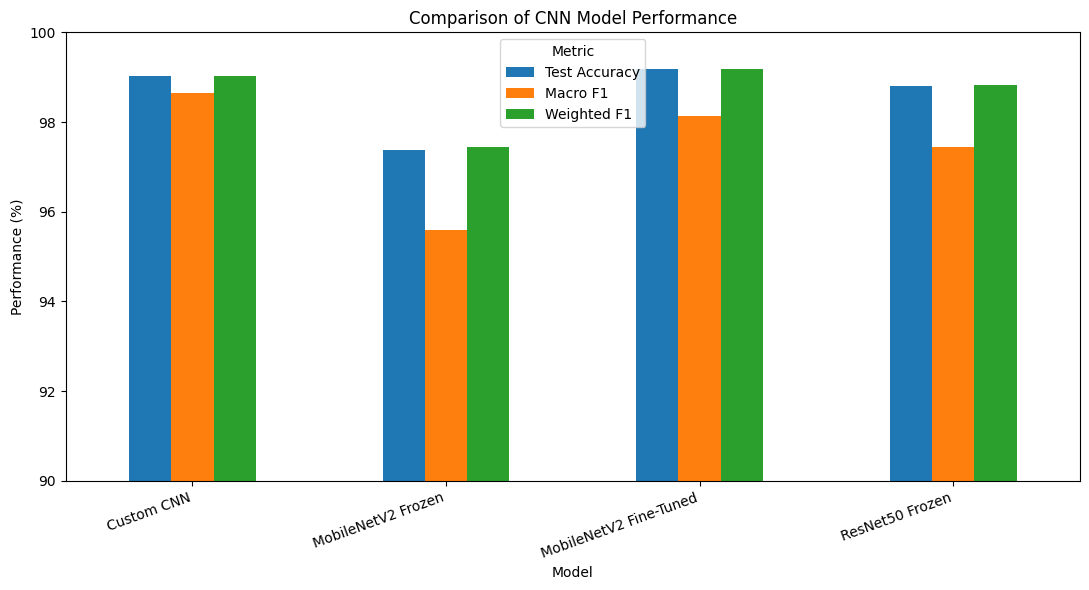

In [6]:
plot_df = display_results.set_index("Model")[
    ["Test Accuracy", "Macro F1", "Weighted F1"]
]

ax = plot_df.plot(
    kind="bar",
    figsize=(11, 6)
)

plt.title("Comparison of CNN Model Performance")
plt.ylabel("Performance (%)")
plt.xlabel("Model")
plt.ylim(90, 100)
plt.xticks(rotation=20, ha="right")
plt.legend(title="Metric")
plt.tight_layout()

plt.show()

### Compare Healthy class specifically

In [7]:
healthy_results = pd.DataFrame([
    {
        "Model": "Custom CNN",
        "Healthy Precision": 0.9474,
        "Healthy Recall": 0.9474,
        "Healthy F1": 0.9474,
    },
    {
        "Model": "MobileNetV2 Frozen",
        "Healthy Precision": 0.6786,
        "Healthy Recall": 1.0000,
        "Healthy F1": 0.8085,
    },
    {
        "Model": "MobileNetV2 Fine-Tuned",
        "Healthy Precision": 0.8571,
        "Healthy Recall": 0.9474,
        "Healthy F1": 0.9000,
    },
    {
        "Model": "ResNet50 Frozen",
        "Healthy Precision": 0.7600,
        "Healthy Recall": 1.0000,
        "Healthy F1": 0.8636,
    },
])

healthy_results

,Model,Healthy Precision,Healthy Recall,Healthy F1
0,Custom CNN,0.9474,0.9474,0.9474
1,MobileNetV2 Frozen,0.6786,1.0000,0.8085
2,MobileNetV2 Fine-Tuned,0.8571,0.9474,0.9000
3,ResNet50 Frozen,0.7600,1.0000,0.8636


In [8]:
healthy_display = healthy_results.copy()

healthy_display[
    ["Healthy Precision", "Healthy Recall", "Healthy F1"]
] *= 100

healthy_display.round(2)

,Model,Healthy Precision,Healthy Recall,Healthy F1
0,Custom CNN,94.74,94.74,94.74
1,MobileNetV2 Frozen,67.86,100.00,80.85
2,MobileNetV2 Fine-Tuned,85.71,94.74,90.00
3,ResNet50 Frozen,76.00,100.00,86.36


### Model file sizes

In [9]:
MODEL_DIR = Path("../backend/trained_models")

model_files = {
    "Custom CNN": MODEL_DIR / "custom_cnn_baseline.keras",
    "MobileNetV2 Frozen": MODEL_DIR / "mobilenetv2_transfer.keras",
    "MobileNetV2 Fine-Tuned": MODEL_DIR / "mobilenetv2_finetuned.keras",
    "ResNet50 Frozen": MODEL_DIR / "resnet50_transfer.keras",
}

model_sizes = []

for model_name, model_path in model_files.items():
    size_mb = model_path.stat().st_size / (1024 ** 2)

    model_sizes.append({
        "Model": model_name,
        "Model Size (MB)": round(size_mb, 2)
    })

model_size_df = pd.DataFrame(model_sizes)

model_size_df

,Model,Model Size (MB)
0,Custom CNN,4.53
1,MobileNetV2 Frozen,9.31
2,MobileNetV2 Fine-Tuned,20.83
3,ResNet50 Frozen,90.80


### Model size chart

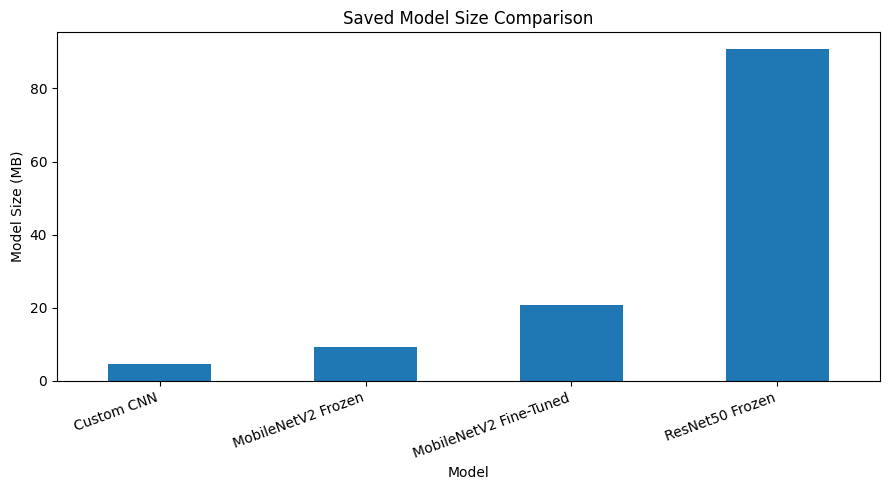

In [10]:
model_size_df.set_index("Model").plot(
    kind="bar",
    figsize=(9, 5),
    legend=False
)

plt.title("Saved Model Size Comparison")
plt.xlabel("Model")
plt.ylabel("Model Size (MB)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()

plt.show()

### Final decision logic

In [11]:
final_comparison = pd.DataFrame([
    {
        "Model": "Custom CNN",
        "Test Accuracy (%)": 99.03,
        "Macro F1 (%)": 98.64,
        "Weighted F1 (%)": 99.03,
        "Model Size (MB)": 4.53,
    },
    {
        "Model": "MobileNetV2 Frozen",
        "Test Accuracy (%)": 97.38,
        "Macro F1 (%)": 95.59,
        "Weighted F1 (%)": 97.44,
        "Model Size (MB)": 9.31,
    },
    {
        "Model": "MobileNetV2 Fine-Tuned",
        "Test Accuracy (%)": 99.18,
        "Macro F1 (%)": 98.14,
        "Weighted F1 (%)": 99.18,
        "Model Size (MB)": 20.83,
    },
    {
        "Model": "ResNet50 Frozen",
        "Test Accuracy (%)": 98.80,
        "Macro F1 (%)": 97.44,
        "Weighted F1 (%)": 98.83,
        "Model Size (MB)": 90.80,
    },
])

final_comparison

,Model,Test Accuracy (%),Macro F1 (%),Weighted F1 (%),Model Size (MB)
0,Custom CNN,99.03,98.64,99.03,4.53
1,MobileNetV2 Frozen,97.38,95.59,97.44,9.31
2,MobileNetV2 Fine-Tuned,99.18,98.14,99.18,20.83
3,ResNet50 Frozen,98.80,97.44,98.83,90.80


## Selected Model: Custom CNN